# BT4221 Project Group 4 — Spark Post-Cleaning EDA

**Note:** This notebook performs Exploratory Data Analysis with the `cleaned_parquet.parquet` parquet created from the `EDA.ipynb` file.  
The parquet file **must** be available in your local directory to successfully run this notebook.

## Problem Statement and Class Definition

Traffic congestion and road safety are critical issues for urban planning and emergency response management. This project leverages a countrywide dataset of US traffic accidents, spanning 49 states and collected via real-time traffic APIs from 2016 to 2023. The primary objective is to determine whether the severity of an accident, gauged by its impact on traffic flow, can be accurately predicted using real-time environmental, temporal, and spatial conditions.

The original dataset records accident severity on a scale from 1 to 4 of increasing traffic delay. To manage severe class imbalance and focus on identifying factors that lead to significant traffic disruption, the target is reclassified into a binary variable:

*   Low Severity (Class 0): Original levels 1 and 2, representing accidents with minor to moderate impact on traffic flow.
*   High Severity (Class 1): Original levels 3 and 4, representing accidents with significant impact on traffic flow.

The following notebook illustrates the Exploratory Data Analysis, cleaning, and preprocessing steps executed on the dataset.

In [1]:
# Visual helper function (Only for printing purposes)
def border(s):
    print(f"{'='*20} {s} {'='*20}")

## Environment Setup

### Google Colab
Run if you are using Google Colab

In [ ]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [ ]:
# # Download and install Spark
# border("Install dependencies")
# !pip3 install pyspark

# # Install findspark
# !pip3 install findspark

# # Initialise findspark
# import findspark
# findspark.init()

# # Set java version
# import os
# java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# os.environ['JAVA_HOME'] = java_path

# # Verify installation
# border("PySpark Version")
# !pip show pyspark
# border("findspark Version")
# !pip show findspark
# border("Hadoop version")
# !hadoop version
# border("Java version")
# !java -version

## Import Libaries

In [4]:
# Import required libraries
from pyspark.sql import SparkSession

import pyspark.sql.functions as F

from pyspark.sql.types import NumericType, TimestampType, StringType, IntegerType, DoubleType, BooleanType
from pyspark.sql.window import Window

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler

from pyspark.storagelevel import StorageLevel
import string
import time
from pathlib import Path
import psutil
import os

# Visulisations only
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Initialise SparkSession

### Dynamic SparkSession Configuration

In [5]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 20
Driver Memory: 44g


### Create SparkSession

In [6]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BT4221_Group4") \
    .config("spark.driver.memory", driver_memory) \
    .config("spark.sql.shuffle.partitions", cores * 3) \
    .config("spark.default.parallelism", cores) \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)

App: BT4221_Group4


## Read Parquet

In [ ]:
# Read directories
PROJECT_ROOT = Path.cwd().parent
CLEANED_PARQUET_PATH = PROJECT_ROOT / "dataset/cleaned_parquet"

if not CLEANED_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Original CSV not found at: {CLEANED_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", CLEANED_PARQUET_PATH)

# Read parquet files
df = spark.read.parquet(str(CLEANED_PARQUET_PATH))

## Categorise Columns

In [8]:
# Categorise column types
numerical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, (IntegerType, DoubleType))]
bool_col = [f.name for f in df.schema.fields if isinstance(f.dataType, BooleanType)]
categorical_col = [f.name for f in df.schema.fields if isinstance(f.dataType, StringType) and f.name != "ID"]

print(f"Numerical columns: {numerical_col}")
print(f"Boolean columns: {bool_col}")
print(f"Categorical columns: {categorical_col}")

Numerical columns: ['Start_Time_Month', 'Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Start_Time_Year', 'Start_Time_Day_of_Week', 'Start_Time_Hour', 'Start_Time_is_Weekend', 'End_Time_Year', 'End_Time_Month', 'End_Time_Day_of_Week', 'End_Time_Hour', 'End_Time_is_Weekend', 'high_severity']
Boolean columns: ['Crossing', 'Junction', 'Station', 'Stop', 'Traffic_Signal']
Categorical columns: ['Airport_Code', 'Street', 'City', 'County', 'State', 'Zipcode', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


## Analysis for Severity Correlation

### Compare Numerical Feature Means across Binarised Severity

In [12]:
weather_spatial = [
    c for c in numerical_col 
    if c in ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)", "Distance(mi)", "Start_Lat", "Start_Lng"]
]

time_based = [
    c for c in numerical_col 
    if c in ["Start_Time_Month", "Start_Time_Day_of_Week", "Start_Time_Hour", "Start_Time_is_Weekend"]
]

skip = ["Severity", "high_severity", "Start_Time_Year", "End_Time_Year", "End_Time_Month", "End_Time_Day_of_Week", "End_Time_Hour", "End_Time_is_Weekend"]


# Table for weather/spatial
numerical_df = df.groupBy("high_severity").agg(
    *[F.round(F.mean(c), 4).alias(c) for c in weather_spatial]
).orderBy("high_severity")

numerical_pd = numerical_df.toPandas()
numerical_pd["high_severity"] = numerical_pd["high_severity"].map({0: "Low severity", 1: "High severity"})
numerical_pd = numerical_pd.set_index("high_severity").T
print(numerical_pd.to_string())


high_severity      Low severity  High severity
Start_Lat               36.0248        36.8435
Start_Lng              -94.7827       -93.0621
Distance(mi)             0.5240         0.4792
Temperature(F)          61.7546        61.6306
Humidity(%)             64.7151        65.7396
Pressure(in)            29.5253        29.6554
Visibility(mi)           9.0983         9.0926
Wind_Speed(mph)          7.5246         8.0447
Precipitation(in)        0.0057         0.0085


In [11]:
def plot_line_graph(df, time_col):
    """Calculates and plots the distribution of accident severity over a time dimension."""
    time_df = df.groupBy("high_severity", time_col).count()
    window_spec = Window.partitionBy("high_severity")
    
    time_df = time_df.withColumn(
        "pct", F.col("count") / F.sum("count").over(window_spec)
    )
    
    time_pd = time_df.toPandas()

    plt.figure(figsize=(12, 4))
    
    severity_labels = {0: "Low severity", 1: "High severity"}
    
    for sev in [0, 1]:
        sub = time_pd[time_pd["high_severity"] == sev].sort_values(time_col)
        plt.plot(sub[time_col], sub["pct"], marker="o", label=severity_labels[sev])
    
    plt.xlabel(time_col.replace("Start_Time_", ""))
    plt.ylabel("Proportion within class")
    plt.title(f"{time_col} Distribution - Low vs High Severity")
    plt.legend()

    if time_col == "Start_Time_Month":
        plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                                  "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    elif time_col == "Start_Time_Day_of_Week":
        plt.xticks(range(1, 8), ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"])
    elif time_col == "Start_Time_is_Weekend":
        plt.xticks([0, 1], ["Weekday", "Weekend"])

    plt.tight_layout()
    plt.show()

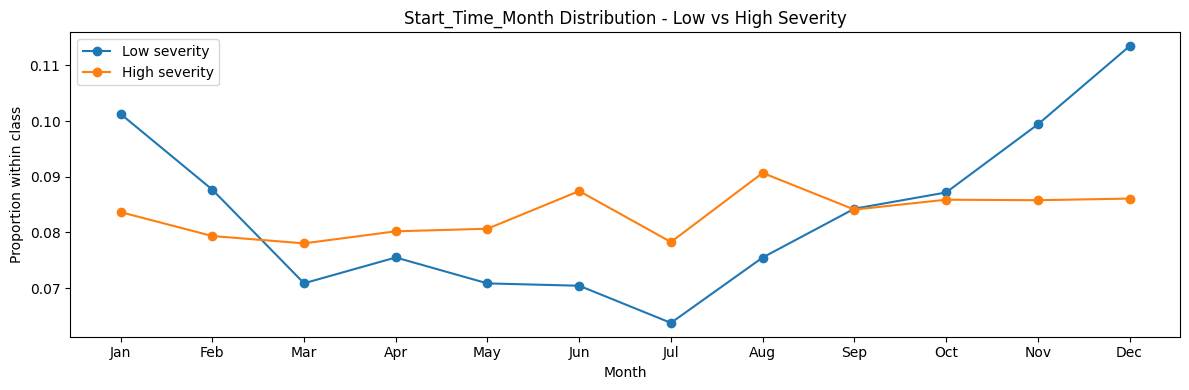

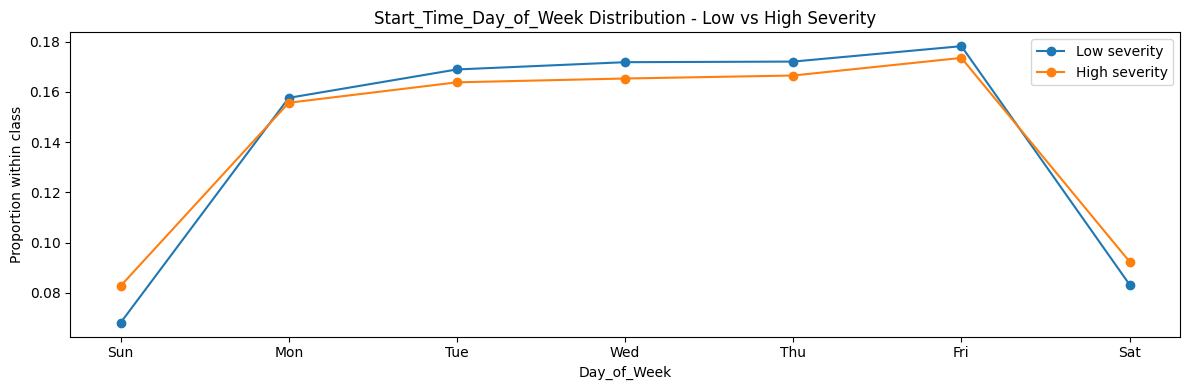

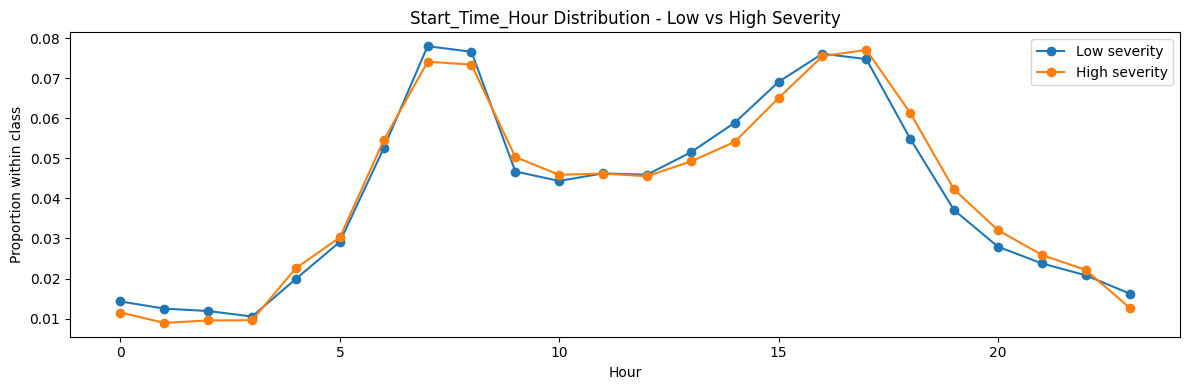

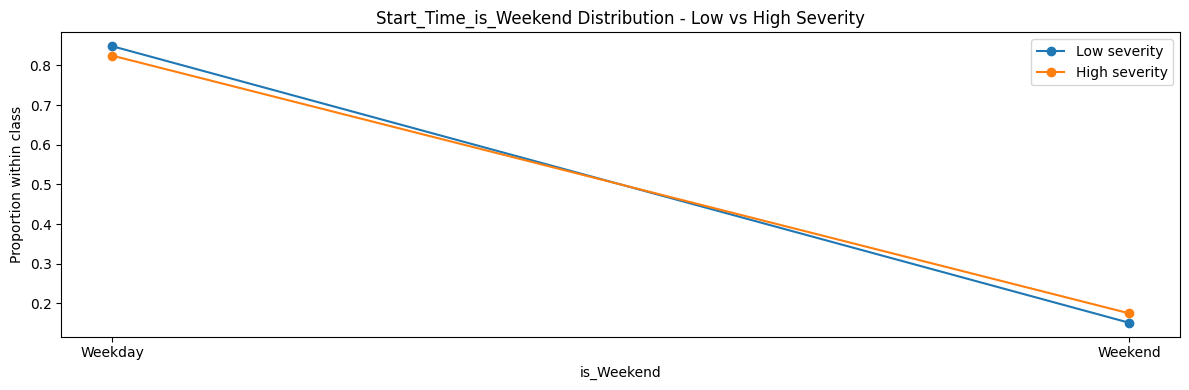

In [ ]:
for col in time_based:
    plot_line_graph(df, col)

* Temperature(F), Humidity(%), Pressure(in), Visibility(mi), and Distance(mi) are nearly identical across low and high severity (differences being in the second or third decimal place)
* Wind_Speed(mph) shows the most noticeable difference (7.314 vs 7.7726). This indicates that high severity accidents tend to occur in sightly windier conditions
* Precipitation(in) is slightly higher for high severity (0.0054 vs 0.0081), but both values are extremely close to 0, indicating most accidents happen in dry conditions regardless of severity

### Compare Boolean Features across Binarised Severity

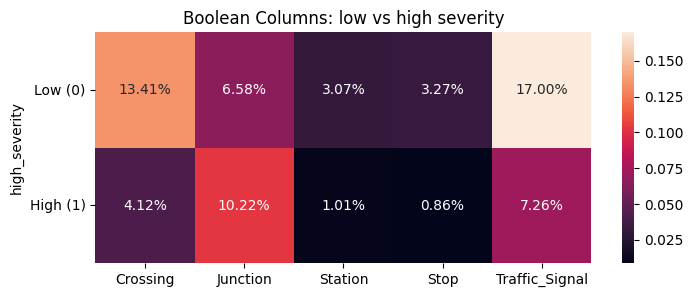

In [13]:
rate = df.groupBy("high_severity").agg(
    *[F.round(F.mean(F.col(p).cast("int")), 4).alias(p) for p in bool_col]
).orderBy("high_severity").toPandas().set_index("high_severity")

plt.figure(figsize=(8, 3))
sns.heatmap(rate, annot=True, fmt=".2%")
plt.title("Boolean Columns: low vs high severity")
plt.yticks([0.5, 1.5], ["Low (0)", "High (1)"], rotation=0)
plt.show()

* Crossing: more common in low severity (12.00% vs 4.10%). It is possible that crossings may slow traffic enough to reduce disruption spread
* Junction: more common in high severity (8.95% vs 6.35%). It is possible that junctions create more complex traffic disruption when accidents occur there
* Traffic Signal: notably more common in low severity (14.08% vs 6.82%). It is possible that signalised intersections may contain disruption better

From this heatmap, it suggests that infrastructure type does influence severity, and Junction in particular appears associated with higher severity accidents

### Compare Categorical Features across Binarised Severity


==================== Airport_Code distribution — low vs high severity (Top 20) ====================


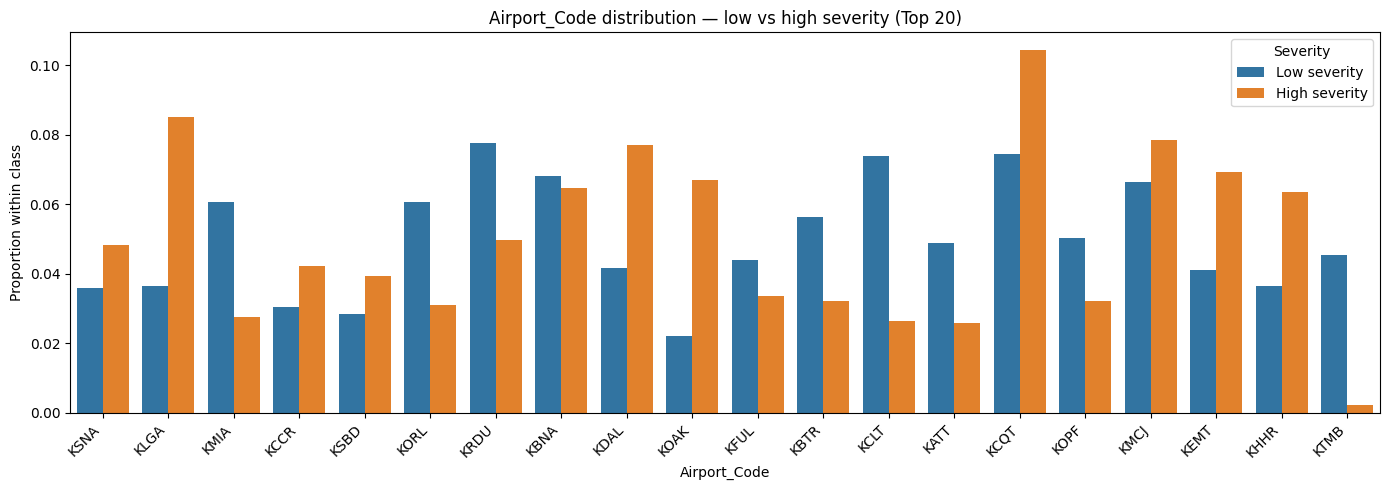


==================== Street distribution — low vs high severity (Top 20) ====================


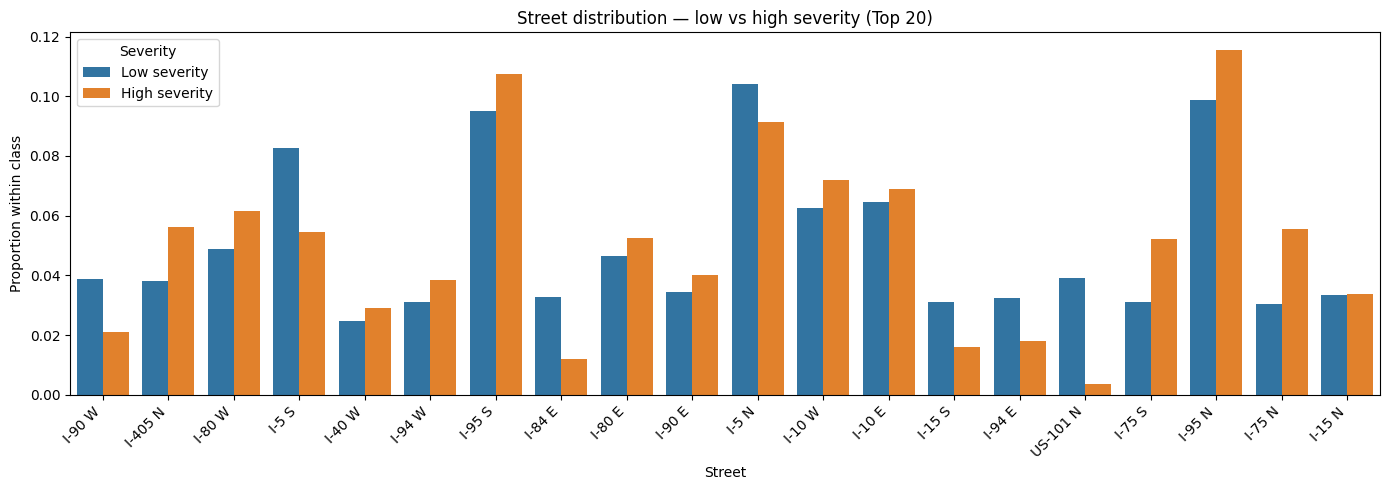


==================== City distribution — low vs high severity (Top 20) ====================


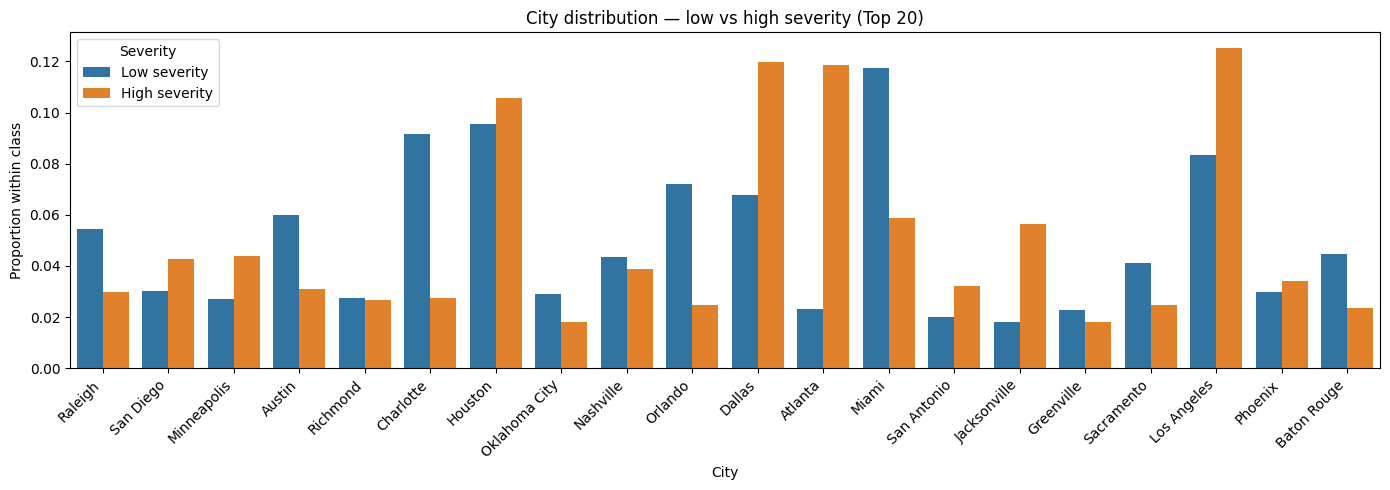


==================== County distribution — low vs high severity (Top 20) ====================


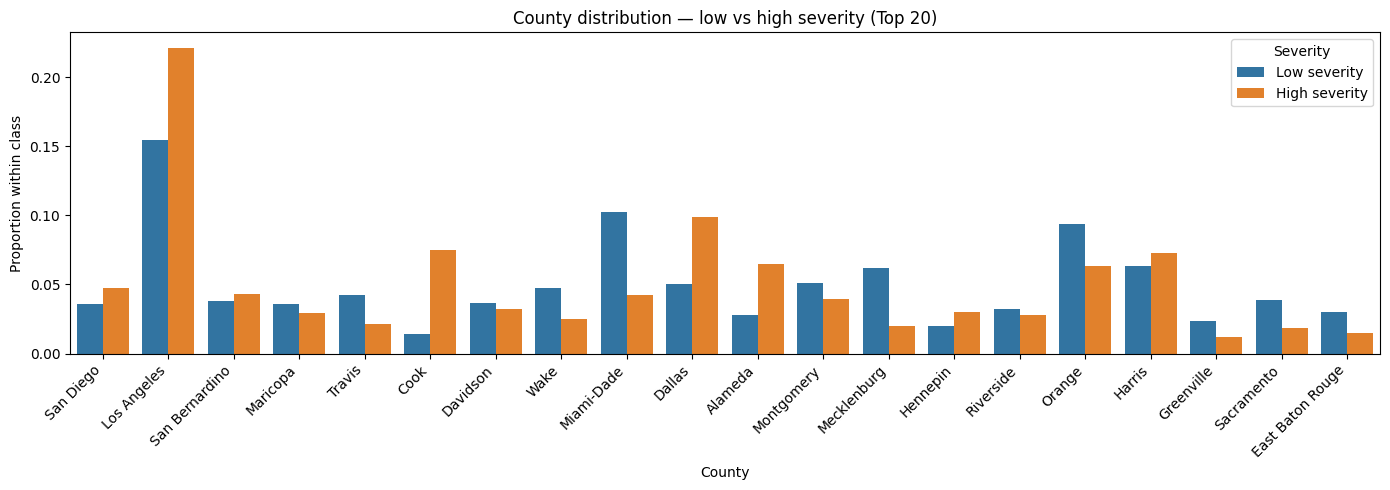


==================== State distribution — low vs high severity (Top 20) ====================


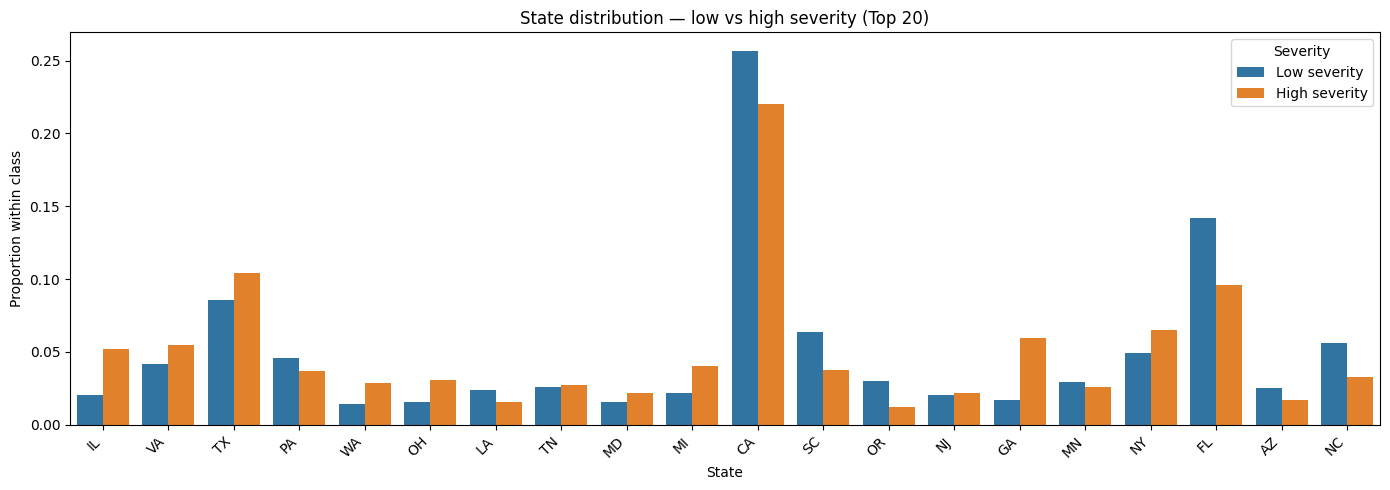


==================== Zipcode distribution — low vs high severity (Top 20) ====================


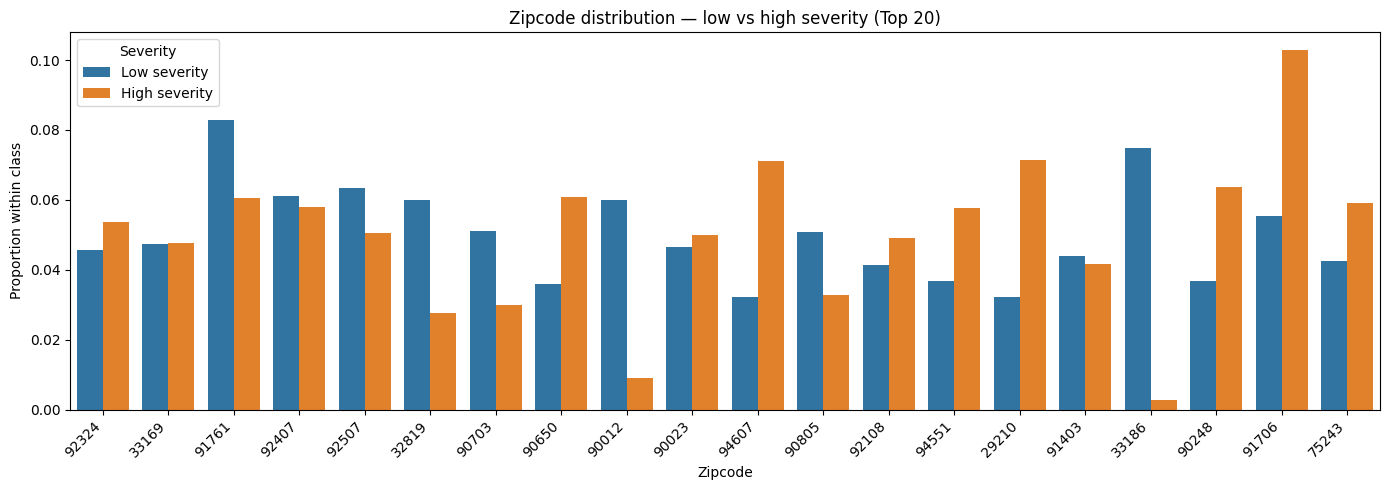


==================== Timezone distribution — low vs high severity  ====================


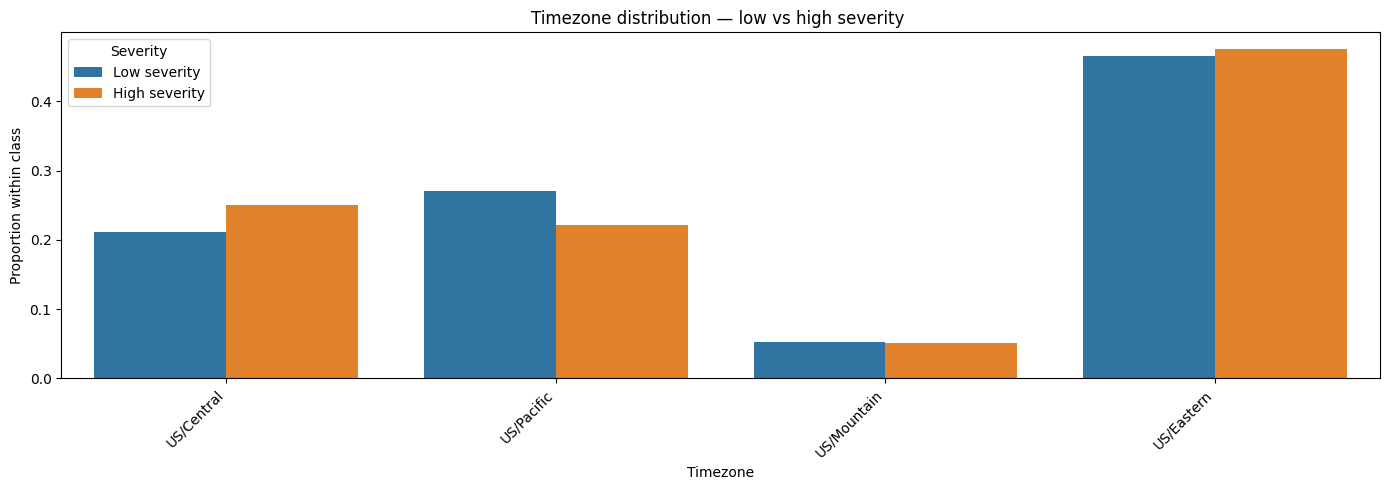


==================== Wind_Direction distribution — low vs high severity  ====================


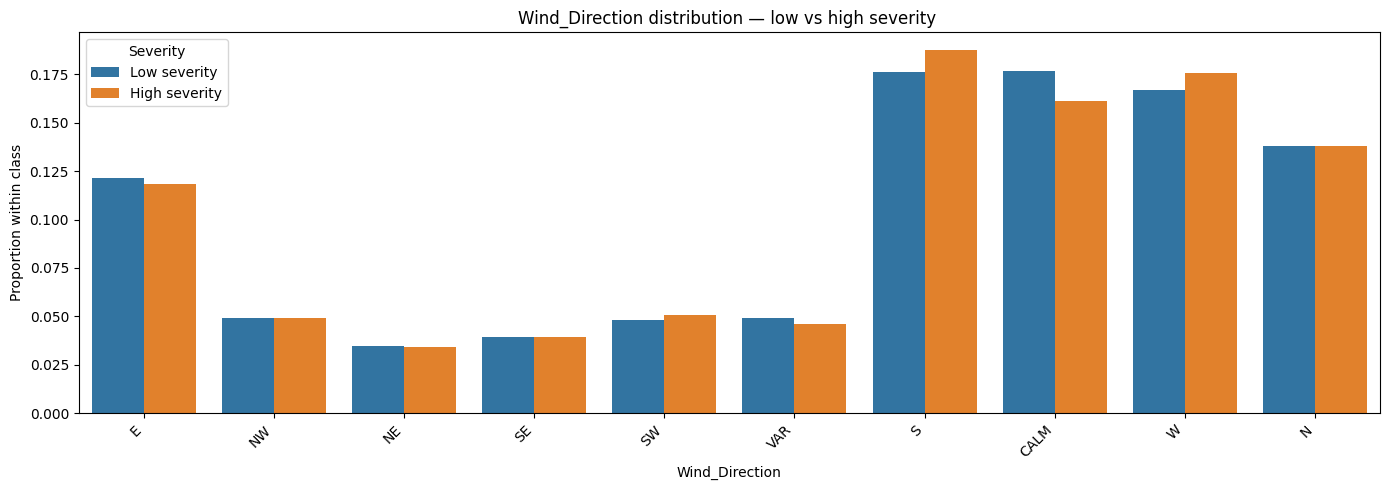


==================== Weather_Condition distribution — low vs high severity (Top 20) ====================


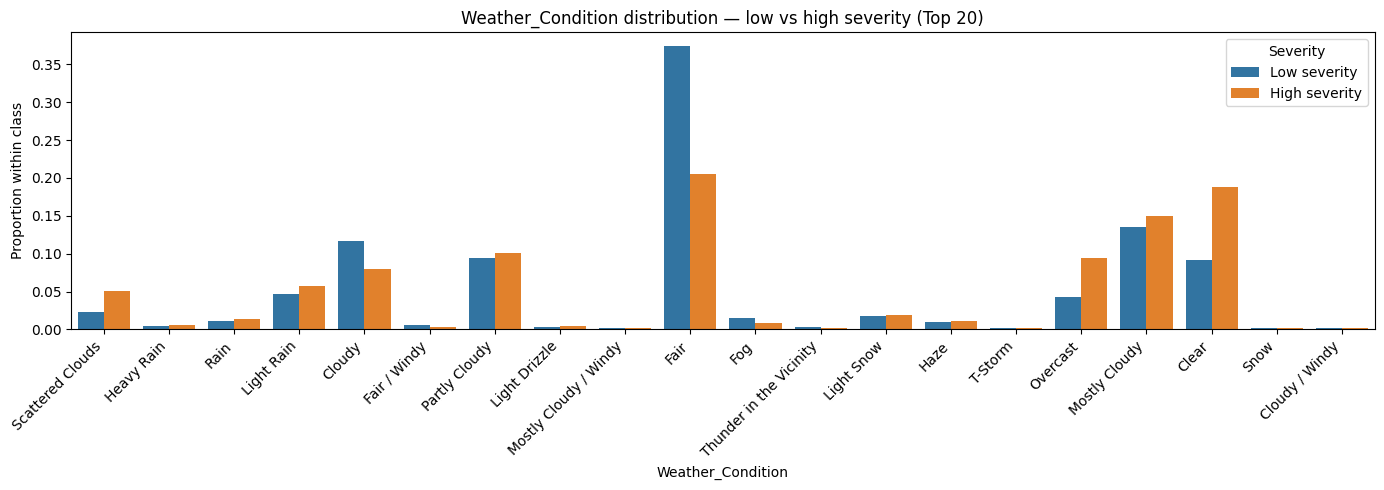


==================== Sunrise_Sunset distribution — low vs high severity  ====================


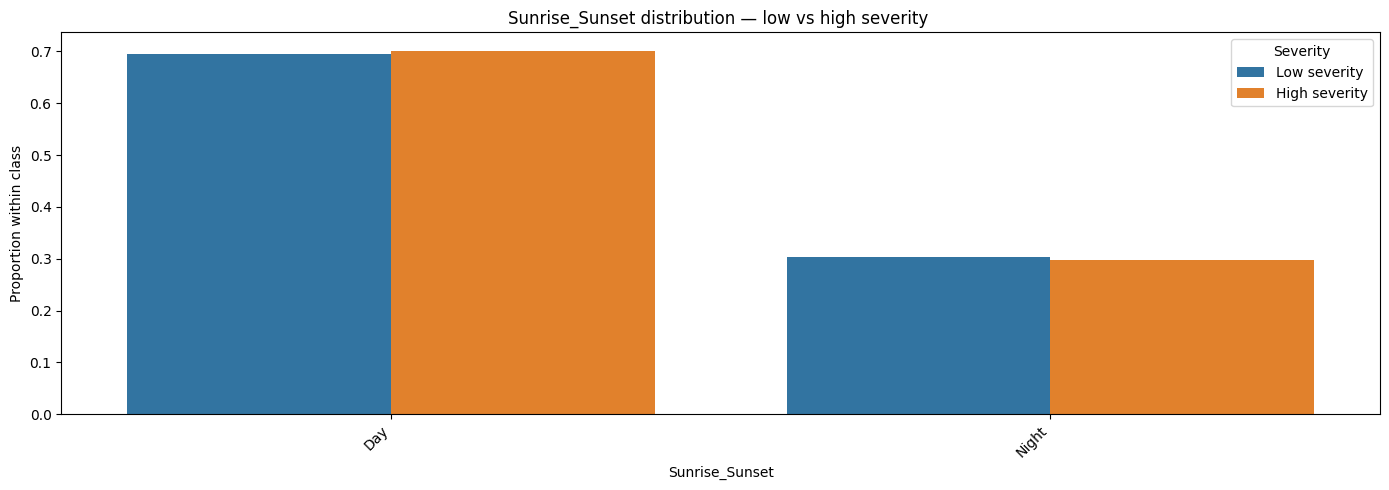


==================== Civil_Twilight distribution — low vs high severity  ====================


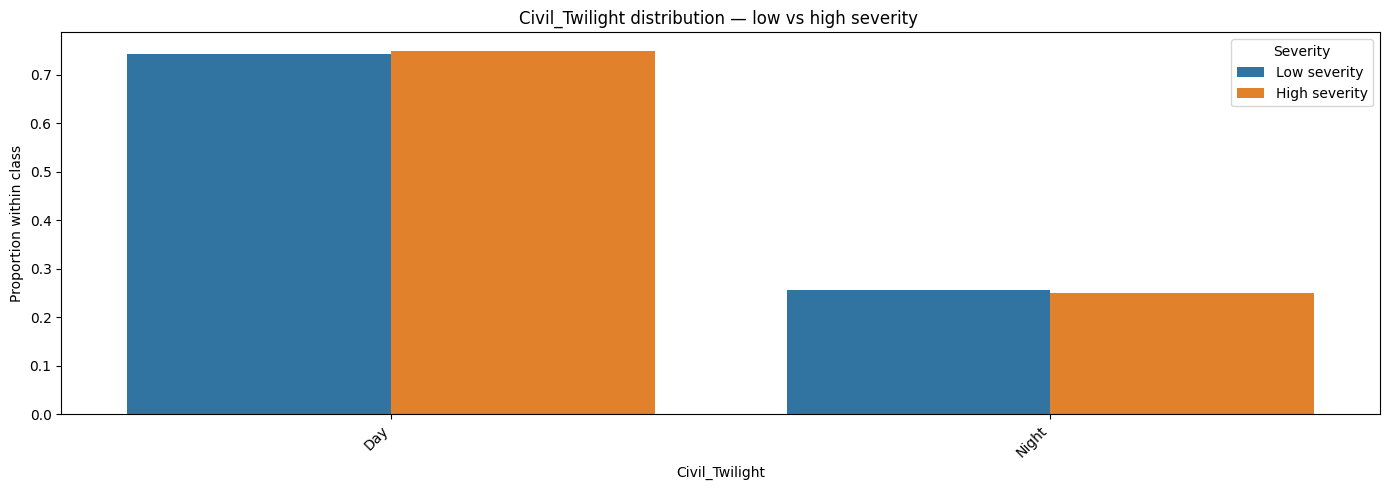


==================== Nautical_Twilight distribution — low vs high severity  ====================


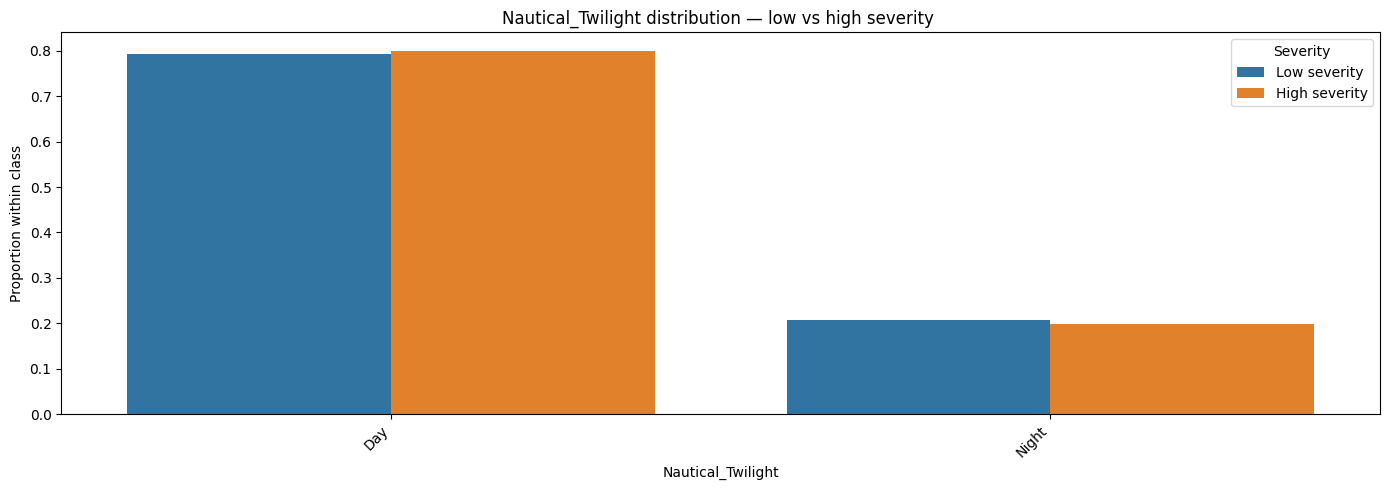


==================== Astronomical_Twilight distribution — low vs high severity  ====================


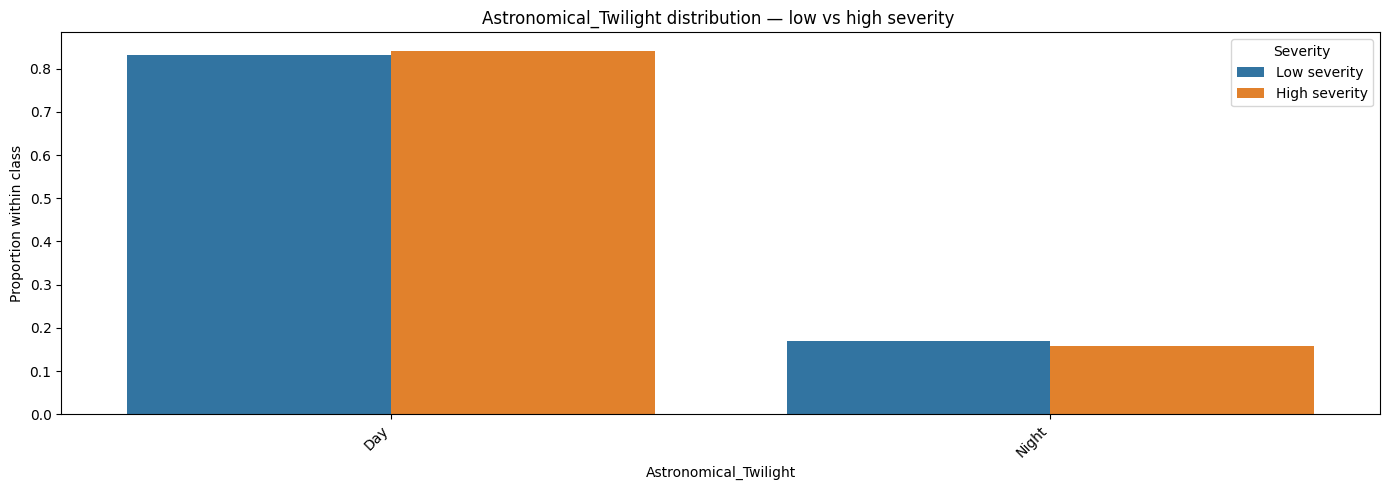

In [14]:
CARDINALITY_THRESHOLD = 20

for c in categorical_col:
    cardinality = df.select(c).distinct().count()
    
    if cardinality > CARDINALITY_THRESHOLD:
        top_vals = [row[c] for row in df.groupBy(c).count() \
            .orderBy(F.desc("count")) \
            .limit(20) \
            .collect()]
        plot_df = df.filter(F.col(c).isin(top_vals))
        title_suffix = "(Top 20)"
    else:
        plot_df = df
        title_suffix = ""

    cat_df = plot_df.groupBy("high_severity", c).count()
    cat_df = cat_df.withColumn("pct", F.col("count") / F.sum("count").over(Window.partitionBy("high_severity")))
    cat_pd = cat_df.toPandas()
    cat_pd["high_severity"] = cat_pd["high_severity"].map({0: "Low severity", 1: "High severity"})

    print()
    border(f"{c} distribution — low vs high severity {title_suffix}")
    plt.figure(figsize=(14, 5))
    sns.barplot(data=cat_pd, x=c, y="pct", hue="high_severity")
    plt.xlabel(c)
    plt.ylabel("Proportion within class")
    plt.title(f"{c} distribution — low vs high severity {title_suffix}")
    plt.legend(title="Severity")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

### Correlation Matrix

==================== Pearson correlation matrix - all features ====================


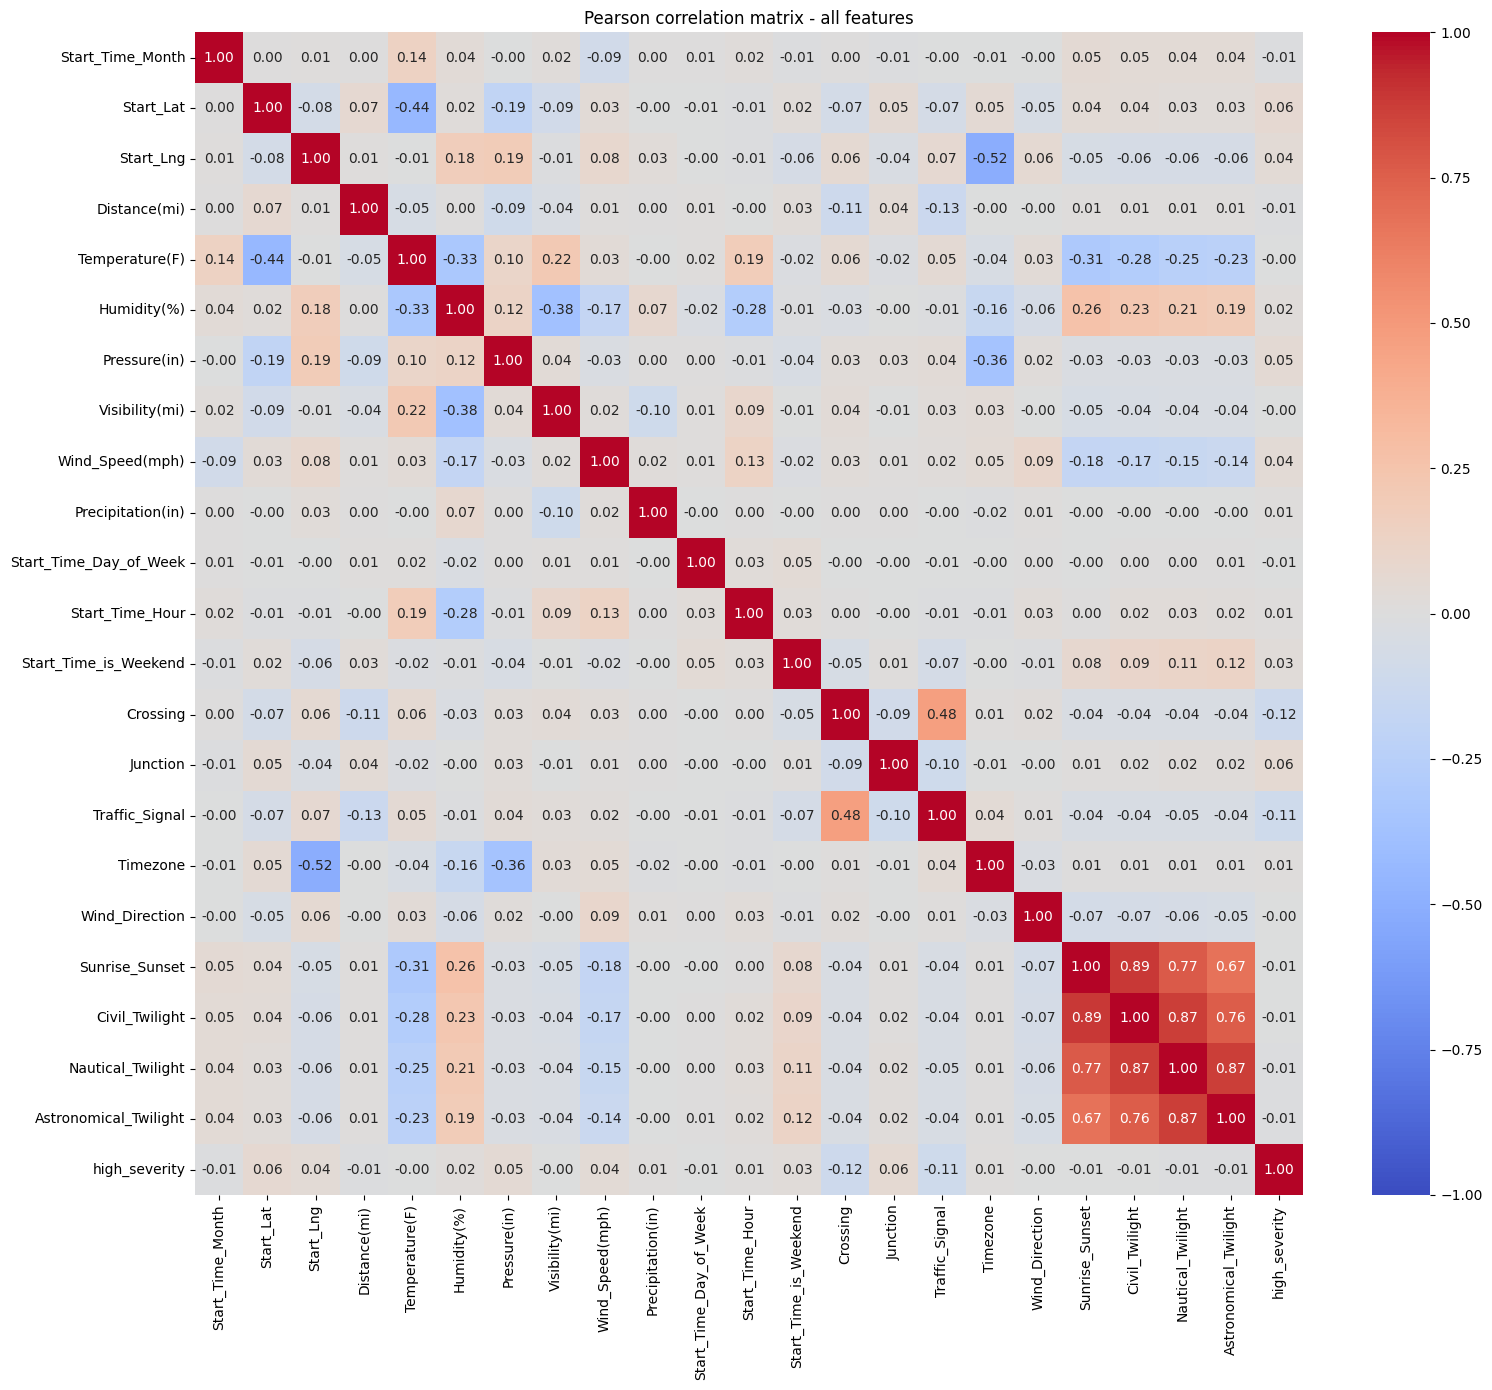

==================== Feature correlation with severity ====================


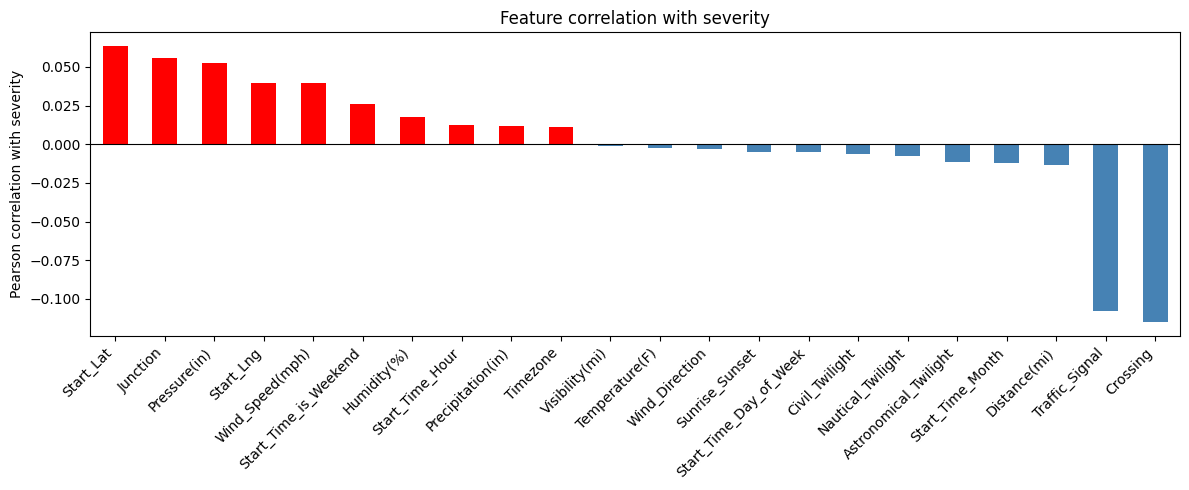

In [15]:
numerical = [c for c in numerical_col if c not in skip]

# Skip high cardinality categoricals
bool_cols = ["Crossing", "Junction", "Traffic_Signal"]
cat_cols = ["Timezone", "Wind_Direction", "Sunrise_Sunset", 
            "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight"]

for c in bool_cols:
    df = df.withColumn(c + "_int", F.col(c).cast("int"))

indexers = [StringIndexer(inputCol=c, outputCol=c + "_idx", handleInvalid="skip") 
            for c in cat_cols]
pipeline = Pipeline(stages=indexers)
df_encoded = pipeline.fit(df).transform(df)

bool_int_cols = [c + "_int" for c in bool_cols]
cat_idx_cols = [c + "_idx" for c in cat_cols]
corr_features = numerical + bool_int_cols + cat_idx_cols + ["high_severity"]

assembler = VectorAssembler(inputCols=corr_features, outputCol="features", handleInvalid="skip")
vec_df = assembler.transform(df_encoded)
corr_matrix = Correlation.corr(vec_df, "features").head()[0].toArray()

clean_names = numerical + bool_cols + cat_cols + ["high_severity"]
corr_pd = pd.DataFrame(corr_matrix, index=clean_names, columns=clean_names)

border("Pearson correlation matrix - all features")
plt.figure(figsize=(16, 14))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation matrix - all features")
plt.tight_layout()
plt.show()

highsev_corr = corr_pd["high_severity"].drop("high_severity").sort_values(ascending=False)

border("Feature correlation with severity")
plt.figure(figsize=(12, 5))
highsev_corr.plot(kind="bar", 
                  color=["red" if v > 0 else "steelblue" for v in highsev_corr])
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Pearson correlation with severity")
plt.title("Feature correlation with severity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Visualisations for Average Duration (Seconds), Average Distance (Miles) and Accident Count against Severity

In [16]:
summary_df = (
    df
    .groupBy("Severity")
    .agg(
        F.count("*").alias("Accident_Count"),
        F.round(F.avg("Duration_Seconds"), 2).alias("Avg_Duration_Seconds"),
        F.round(F.avg("Distance(mi)"), 2).alias("Avg_Distance")
    )
    .orderBy("Severity")
)

summary_df.show()

+--------+--------------+--------------------+------------+
|Severity|Accident_Count|Avg_Duration_Seconds|Avg_Distance|
+--------+--------------+--------------------+------------+
|       1|         62649|             2778.93|        0.11|
|       2|       5712602|             7307.33|        0.53|
|       3|       1225397|             4104.64|        0.35|
|       4|        182996|            13425.61|        1.32|
+--------+--------------+--------------------+------------+



==================== Average Durations (Seconds) ====================


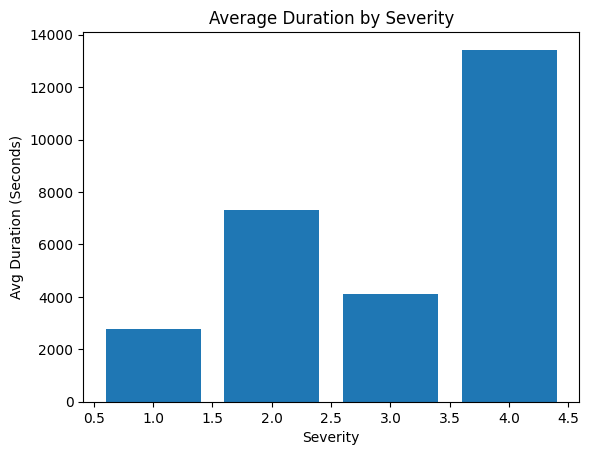


==================== Average Distance (Miles) ====================


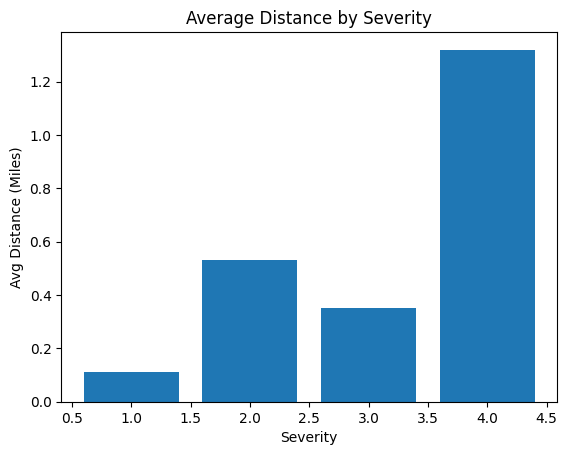


==================== Accident Count ====================


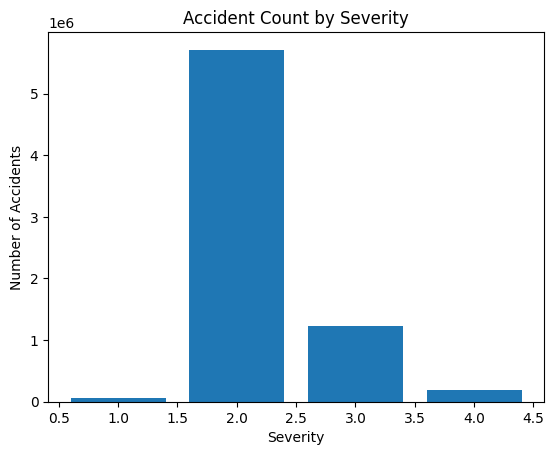

In [17]:
pd = summary_df.toPandas()

border("Average Durations (Seconds)")
plt.figure()
plt.bar(pd["Severity"], pd["Avg_Duration_Seconds"])
plt.xlabel("Severity")
plt.ylabel("Avg Duration (Seconds)")
plt.title("Average Duration by Severity")
plt.show()

print()
border("Average Distance (Miles)")
plt.figure()
plt.bar(pd["Severity"], pd["Avg_Distance"])
plt.xlabel("Severity")
plt.ylabel("Avg Distance (Miles)")
plt.title("Average Distance by Severity")
plt.show()

print()
border("Accident Count")
plt.figure()
plt.bar(pd["Severity"], pd["Accident_Count"])
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")
plt.title("Accident Count by Severity")
plt.show()

## Stop Spark

In [ ]:
spark.stop()